<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 40%, #0f3460 100%); padding: 50px 40px; border-radius: 20px; text-align: center; margin-bottom: 20px; border: 2px solid #e94560;">
  <h1 style="color: #e94560; font-size: 2.8em; font-weight: 900; margin: 0 0 10px 0; letter-spacing: 2px;">🎤 RapFlow-TTS</h1>
  <h2 style="color: #a8dadc; font-size: 1.6em; font-weight: 400; margin: 0 0 20px 0;">Consistency Flow Matching for Text-to-Speech Synthesis</h2>
  <p style="color: #b0b0c0; font-size: 1.1em; max-width: 800px; margin: 0 auto 20px auto; line-height: 1.6;">
    An end-to-end, step-by-step walkthrough of the RapFlow-TTS pipeline covering <strong style='color:#e94560'>Dataset Setup</strong>,
    <strong style='color:#e94560'>Preprocessing</strong>, <strong style='color:#e94560'>Architecture</strong>,
    <strong style='color:#e94560'>Training</strong> (3-stage), <strong style='color:#e94560'>Inference</strong> &amp; <strong style='color:#e94560'>Evaluation</strong>.
  </p>
  <div style='display:inline-block; background:#e94560; color:white; padding: 8px 24px; border-radius:30px; font-size:1em; font-weight:700;'>MSc Semester 2 | TTS Research Presentation</div>
</div>

---
## 📋 Notebook Structure

| Step | Section | Purpose |
|------|---------|------|
| 0 | Environment Setup | Install dependencies, configure paths |
| 1 | Dataset Guide | Download LJSpeech / use synthetic demo data |
| 2 | Text Processing | G2P phonemization, symbol visualizations |
| 3 | Audio Processing | Mel-spectrogram extraction, waveform display |
| 4 | Model Architecture | Text Encoder → Aligner → Flow Decoder |
| 5 | Monotonic Alignment (MAS) | Alignment heatmap visualization |
| 6 | Flow Matching Trajectory | t=0→1 stepwise noise-to-mel visualization |
| 7 | Stage 1 Training | Straight-flow pre-training with live loss curves |
| 8 | Stage 2 Training | Consistency FM with EMA teacher |
| 9 | Stage 3 Training | Adversarial refinement (GAN) |
| 10 | Inference & Synthesis | Live text-to-speech with audio playback |
| 11 | Evaluation | WER, RTF, MOS setup |

---

## ⚙️ Step 0 — Environment Setup
Run this cell once to install all required dependencies.

In [1]:
import sys
import subprocess

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + list(pkgs), check=True)

print("📦 Checking / installing core dependencies...")
pip_install(
    "torch>=2.1", "torchaudio>=2.1",
    "numpy", "scipy", "einops",
    "librosa", "soundfile",
    "matplotlib", "tqdm",
    "pyyaml", "tensorboard",
    "numba"
)

# Try phonemizer (needs espeak-ng backend on system)
try:
    pip_install("phonemizer")
    import phonemizer
    from phonemizer import phonemize
    test = phonemize("hello", language="en-us", backend="espeak")
    PHONEMIZER_OK = True
    print("✅ phonemizer + espeak-ng available.")
except Exception as e:
    PHONEMIZER_OK = False
    print(f"⚠️  phonemizer/espeak-ng not fully available ({e}).")
    print("   Using character-level fallback tokenizer for demo cells.")

print("\n✅ All packages ready!")

# ─── Confirm GPU ────────────────────────────────────────────────────────────
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  PyTorch {torch.__version__} | Device: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   ⚠️  No GPU detected — training will be slow. Use CPU for demo/visualization only.")

📦 Checking / installing core dependencies...
⚠️  phonemizer/espeak-ng not fully available (espeak not installed on your system).
   Using character-level fallback tokenizer for demo cells.

✅ All packages ready!

🖥️  PyTorch 2.14.0+cu126 | Device: CUDA
   GPU: NVIDIA GeForce GTX 1650
   VRAM: 4.3 GB


In [2]:
# ─── Paths Configuration ─────────────────────────────────────────────────────
import os, sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Root of the RapFlow-TTS project
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Dataset & checkpoint directories
LJS_DIR  = ROOT / "data" / "LJSpeech-1.1"          # ← set to your extracted LJSpeech folder
PROC_DIR = ROOT / "data" / "processed" / "ljspeech"
CKPT_DIR = ROOT / "checkpoints"
DEMO_DIR = ROOT / "data" / "demo_dataset"

for d in [PROC_DIR, CKPT_DIR, DEMO_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"📂 Project root : {ROOT}")
print(f"📂 LJSpeech dir : {LJS_DIR}")
print(f"📂 Processed dir: {PROC_DIR}")
print(f"📂 Checkpoint dir: {CKPT_DIR}")
print(f"📂 Demo data dir : {DEMO_DIR}")

LJS_AVAILABLE = (LJS_DIR / "metadata.csv").exists()
print(f"\n{'✅' if LJS_AVAILABLE else '⏳'} LJSpeech dataset {'FOUND' if LJS_AVAILABLE else 'NOT YET FOUND — Demo mode active'}")

📂 Project root : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts
📂 LJSpeech dir : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1
📂 Processed dir: C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\processed\ljspeech
📂 Checkpoint dir: C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\checkpoints
📂 Demo data dir : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\demo_dataset

✅ LJSpeech dataset FOUND


---
## 📥 Step 1 — Dataset Setup & Download Guide

<div style='background:#1e3a5f; border-left:5px solid #3ea6ff; padding:20px; border-radius:8px; margin:10px 0'>
<h3 style='color:#3ea6ff; margin:0 0 10px 0'>📊 Recommended Dataset: LJSpeech 1.1</h3>

| Property | Value |
|----------|-------|
| **Speaker** | Single female speaker (LJ) |
| **Samples** | 13,100 audio clips |
| **Duration** | ~24 hours |
| **Sample Rate** | 22,050 Hz |
| **Size** | ~2.6 GB (compressed) |
| **License** | Public Domain |
| **Download URL** | https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2 |

```
Expected directory structure:
Rap_flow_tts/
└── data/
    └── LJSpeech-1.1/
        ├── metadata.csv          ← pipe-separated: id|text|normalized_text
        └── wavs/
            ├── LJ001-0001.wav
            └── ...
```
</div>

<div style='background:#2d3b1e; border-left:5px solid #77cc44; padding:20px; border-radius:8px; margin:10px 0'>
<h3 style='color:#77cc44; margin:0 0 10px 0'>🎙️ Alternative: VCTK (Multi-Speaker)</h3>

| Property | Value |
|----------|-------|
| **Speakers** | 110 speakers |
| **Samples** | ~44,000 clips |
| **Size** | ~11 GB |
| **Download** | https://datashare.ed.ac.uk/handle/10283/3443 |
| **Use when** | Training multi-speaker TTS (set `n_spk=110` in config) |
</div>

In [3]:
# ─── Download LJSpeech (if not already present) ──────────────────────────────
# NOTE: Only run this if you have not already downloaded and extracted LJSpeech!
# Uncomment the lines below to auto-download (~2.6 GB).

import urllib.request
import tarfile
import os

LJS_URL = "https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2"
LJS_TAR = ROOT / "data" / "LJSpeech-1.1.tar.bz2"

def download_ljspeech():
    if LJS_AVAILABLE:
        print("✅ LJSpeech already extracted. Skipping download.")
        return
    if LJS_TAR.exists():
        print(f"📦 Found {LJS_TAR.name}, extracting...")
    else:
        print(f"⬇️  Downloading LJSpeech 1.1 (~2.6 GB) — this may take a while...")
        def reporthook(count, block_size, total_size):
            percent = int(count * block_size * 100 / total_size)
            print(f"\r  Progress: {percent}%", end="", flush=True)
        urllib.request.urlretrieve(LJS_URL, LJS_TAR, reporthook=reporthook)
        print("\n  ✅ Download complete!")

    print("📦 Extracting archive...")
    with tarfile.open(LJS_TAR, "r:bz2") as tar:
        tar.extractall(ROOT / "data")
    print(f"✅ Extracted to {ROOT / 'data' / 'LJSpeech-1.1'}")

# ── Uncomment to trigger download:
# download_ljspeech()

print("ℹ️  To download LJSpeech automatically, uncomment the last line above and re-run.")
print(f"ℹ️  Or copy your extracted folder to: {LJS_DIR}")

ℹ️  To download LJSpeech automatically, uncomment the last line above and re-run.
ℹ️  Or copy your extracted folder to: C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1


In [4]:
# ─── Use REAL LJSpeech Dataset ───────────────────────────────────────────────
import random
from pathlib import Path

# ---------------------------------------------------------------------------
# SET THIS TO YOUR ACTUAL LJSPEECH ROOT DIRECTORY
# ---------------------------------------------------------------------------
LJSPEECH_DIR = Path(
    r"C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1"
)

# Standard LJSpeech files
METADATA_FILE = LJSPEECH_DIR / "metadata.csv"
WAVS_DIR      = LJSPEECH_DIR / "wavs"

# ---------------------------------------------------------------------------
# Verify dataset
# ---------------------------------------------------------------------------

print("Checking LJSpeech dataset...")
print(f"Dataset root : {LJSPEECH_DIR}")
print(f"metadata.csv : {METADATA_FILE}")
print(f"wavs/        : {WAVS_DIR}")

if not LJSPEECH_DIR.exists():
    raise FileNotFoundError(
        f"\nLJSpeech directory does not exist:\n{LJSPEECH_DIR}\n\n"
        "Change LJSPEECH_DIR to the folder containing metadata.csv and wavs/."
    )

if not METADATA_FILE.exists():
    raise FileNotFoundError(
        f"\nmetadata.csv not found:\n{METADATA_FILE}"
    )

if not WAVS_DIR.exists():
    raise FileNotFoundError(
        f"\nwavs directory not found:\n{WAVS_DIR}"
    )

# Count WAV files
wav_files = list(WAVS_DIR.glob("*.wav"))

print(f"\n✅ LJSpeech dataset found")
print(f"   WAV files: {len(wav_files):,}")

# ---------------------------------------------------------------------------
# Create processed filelists if they don't already exist
# ---------------------------------------------------------------------------

PROC_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILELIST = PROC_DIR / "train_filelist.txt"
VAL_FILELIST   = PROC_DIR / "val_filelist.txt"

if not TRAIN_FILELIST.exists() or not VAL_FILELIST.exists():

    print("\nCreating LJSpeech filelists...")

    import csv

    entries = []

    with open(METADATA_FILE, "r", encoding="utf-8") as f:
        reader = csv.reader(f, delimiter="|")

        for row in reader:
            if len(row) < 2:
                continue

            wav_id = row[0]
            text   = row[1]

            wav_path = WAVS_DIR / f"{wav_id}.wav"

            if wav_path.exists():
                entries.append((str(wav_path), text))

    if len(entries) == 0:
        raise RuntimeError(
            "metadata.csv was read, but no matching WAV files were found."
        )

    # Deterministic split
    random.seed(42)
    random.shuffle(entries)

    n_val = max(100, int(len(entries) * 0.01))
    val_entries   = entries[:n_val]
    train_entries = entries[n_val:]

    with open(TRAIN_FILELIST, "w", encoding="utf-8") as f:
        for wav_path, text in train_entries:
            f.write(f"{wav_path}|{text}\n")

    with open(VAL_FILELIST, "w", encoding="utf-8") as f:
        for wav_path, text in val_entries:
            f.write(f"{wav_path}|{text}\n")

    print(f"✅ Created training filelist: {len(train_entries):,} files")
    print(f"✅ Created validation filelist: {len(val_entries):,} files")

else:
    print("\n✅ Existing real LJSpeech filelists found.")

# ---------------------------------------------------------------------------
# Use REAL DATA — no synthetic fallback
# ---------------------------------------------------------------------------

TRAIN_FILELIST = str(TRAIN_FILELIST)
VAL_FILELIST   = str(VAL_FILELIST)

print("\n" + "=" * 70)
print("REAL DATA MODE")
print("=" * 70)
print(f"Train filelist: {TRAIN_FILELIST}")
print(f"Val filelist  : {VAL_FILELIST}")
print("=" * 70)

# Show examples
with open(TRAIN_FILELIST, "r", encoding="utf-8") as f:
    for i in range(3):
        line = f.readline().strip()
        if line:
            wav_path, text = line.split("|", 1)
            print(f"\nExample {i+1}")
            print(" WAV :", wav_path)
            print(" TEXT:", text)

Checking LJSpeech dataset...
Dataset root : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1
metadata.csv : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1\metadata.csv
wavs/        : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1\wavs

✅ LJSpeech dataset found
   WAV files: 13,100

✅ Existing real LJSpeech filelists found.

REAL DATA MODE
Train filelist: C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\processed\ljspeech\train_filelist.txt
Val filelist  : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\processed\ljspeech\val_filelist.txt

Example 1
 WAV : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1\wavs\LJ008-0166.wav
 TEXT: The pieman stooped down to pick up his scattered stock, and some of the mob, not seeing what had happened, stumbled over him.

Example 2
 WAV : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1\w

---
## 📝 Step 2 — Text Processing & Phoneme Visualization

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── Phonemizer with graceful Windows fallback ───────────────────────────────
if PHONEMIZER_OK:
    from data.text_processing import text_to_phoneme_ids, SYMBOLS, SYMBOL_TO_ID
    def get_phonemes(text):
        from phonemizer import phonemize
        from phonemizer.separator import Separator
        return phonemize(text, language="en-us", backend="espeak",
                         separator=Separator(phone="", word=" "),
                         strip=True, preserve_punctuation=True, with_stress=True)
else:
    # Character-level fallback (no espeak needed)
    SYMBOLS = list(" abcdefghijklmnopqrstuvwxyz.,?!'")
    SYMBOL_TO_ID = {s: i for i, s in enumerate(SYMBOLS)}
    def get_phonemes(text):
        return text.lower()
    def text_to_phoneme_ids(text):
        return [SYMBOL_TO_ID.get(c, 0) for c in text.lower() if c in SYMBOL_TO_ID]

# ─── Example text ─────────────────────────────────────────────────────────────
example_text = "Hello, this is a RapFlow text-to-speech demonstration."
phoneme_str  = get_phonemes(example_text)
phoneme_ids  = text_to_phoneme_ids(example_text)

print(f"📄 Input text    : {example_text}")
print(f"🔤 Phonemes      : {phoneme_str}")
print(f"🔢 Phoneme IDs   : {phoneme_ids[:20]} ...")
print(f"📊 Total symbols : {len(SYMBOLS)} | Sequence length: {len(phoneme_ids)}")

📄 Input text    : Hello, this is a RapFlow text-to-speech demonstration.
🔤 Phonemes      : hello, this is a rapflow text-to-speech demonstration.
🔢 Phoneme IDs   : [8, 5, 12, 12, 15, 28, 0, 20, 8, 9, 19, 0, 9, 19, 0, 1, 0, 18, 1, 16] ...
📊 Total symbols : 32 | Sequence length: 52


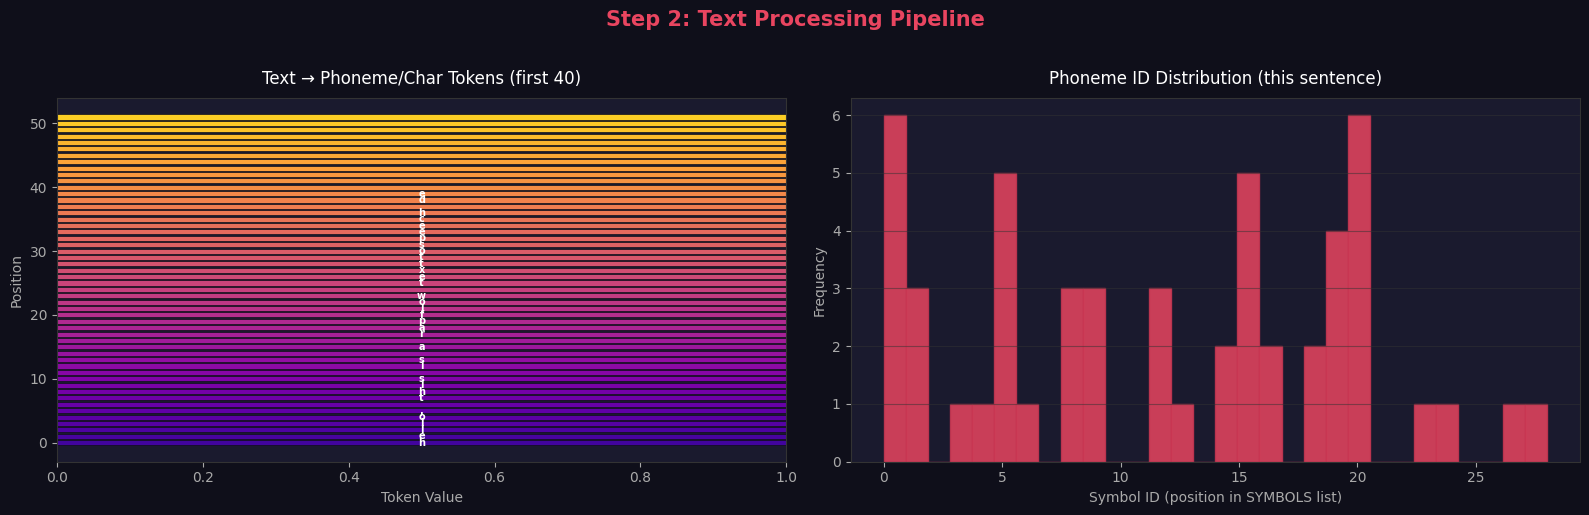

In [6]:
# ─── Visualization: Text → Phoneme → ID pipeline ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes:
    ax.set_facecolor('#1a1a2e')

# Plot 1: Character/phoneme token strip
ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(phoneme_ids)))
ax.barh(range(len(phoneme_ids)), [1] * len(phoneme_ids),
        color=colors, edgecolor='#0f0f1a', linewidth=0.5)
for i, (sid) in enumerate(phoneme_ids[:40]):
    sym = SYMBOLS[sid] if sid < len(SYMBOLS) else '?'
    ax.text(0.5, i, repr(sym).strip("'"),
            ha='center', va='center', fontsize=7, color='white', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_title('Text → Phoneme/Char Tokens (first 40)', color='white', fontsize=12, pad=10)
ax.set_xlabel('Token Value', color='#aaa')
ax.set_ylabel('Position', color='#aaa')
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Plot 2: Symbol ID distribution histogram
ax = axes[1]
ax.hist(phoneme_ids, bins=30, color='#e94560', edgecolor='#c73652', alpha=0.85)
ax.set_title('Phoneme ID Distribution (this sentence)', color='white', fontsize=12, pad=10)
ax.set_xlabel('Symbol ID (position in SYMBOLS list)', color='#aaa')
ax.set_ylabel('Frequency', color='#aaa')
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.grid(axis='y', color='#333', alpha=0.5)

plt.suptitle('Step 2: Text Processing Pipeline', color='#e94560', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🎵 Step 3 — Audio Processing & Mel-Spectrogram

In [7]:
import sys
import torch
import torchaudio

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("TorchAudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

try:
    import torchcodec
    print("TorchCodec:", torchcodec.__version__)
except Exception as e:
    print("TorchCodec error:", e)

Python: c:\Users\Stuxs\miniconda3\envs\pytorch_cuda\python.exe
PyTorch: 2.14.0+cu126
TorchAudio: 2.11.0+cu126
CUDA available: True
CUDA version: 12.6
TorchCodec: 0.16.0+cpu


In [8]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.14.0+cu126
True


In [9]:
import sys
import torch
import torchaudio
import torchcodec

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("TorchAudio:", torchaudio.__version__)
print("TorchCodec:", torchcodec.__version__)

Python: c:\Users\Stuxs\miniconda3\envs\pytorch_cuda\python.exe
PyTorch: 2.14.0+cu126
TorchAudio: 2.11.0+cu126
TorchCodec: 0.16.0+cpu


In [10]:
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from data.audio_processing import wav_to_mel, MEL_CONFIG

# Load first sample (real LJSpeech or demo)
with open(TRAIN_FILELIST) as f:
    first_line = f.readline().strip()
wav_path, text_sample = first_line.split("|")[:2]

wav, sr = torchaudio.load(wav_path)
if sr != MEL_CONFIG["sample_rate"]:
    wav = torchaudio.functional.resample(wav, sr, MEL_CONFIG["sample_rate"])
    sr = MEL_CONFIG["sample_rate"]

mel = wav_to_mel(wav)  # (80, T_frames)
wav_np = wav.squeeze().numpy()
time   = np.arange(len(wav_np)) / sr

print(f'📁 File   : {wav_path}')
print(f'💬 Text   : {text_sample[:80]}')
print(f'⏱️  Duration: {len(wav_np)/sr:.2f}s | SR: {sr} Hz')
print(f'🎛️  Mel shape: {mel.shape} (n_mels={mel.shape[0]}, frames={mel.shape[1]})')

display(Audio(wav_np, rate=sr))

📁 File   : C:\Users\Stuxs\Documents\MSC SEM 1\MSc Sem 2\Rap_flow_tts\data\LJSpeech-1.1\wavs\LJ008-0166.wav
💬 Text   : The pieman stooped down to pick up his scattered stock, and some of the mob, not
⏱️  Duration: 7.84s | SR: 22050 Hz
🎛️  Mel shape: torch.Size([80, 676]) (n_mels=80, frames=676)


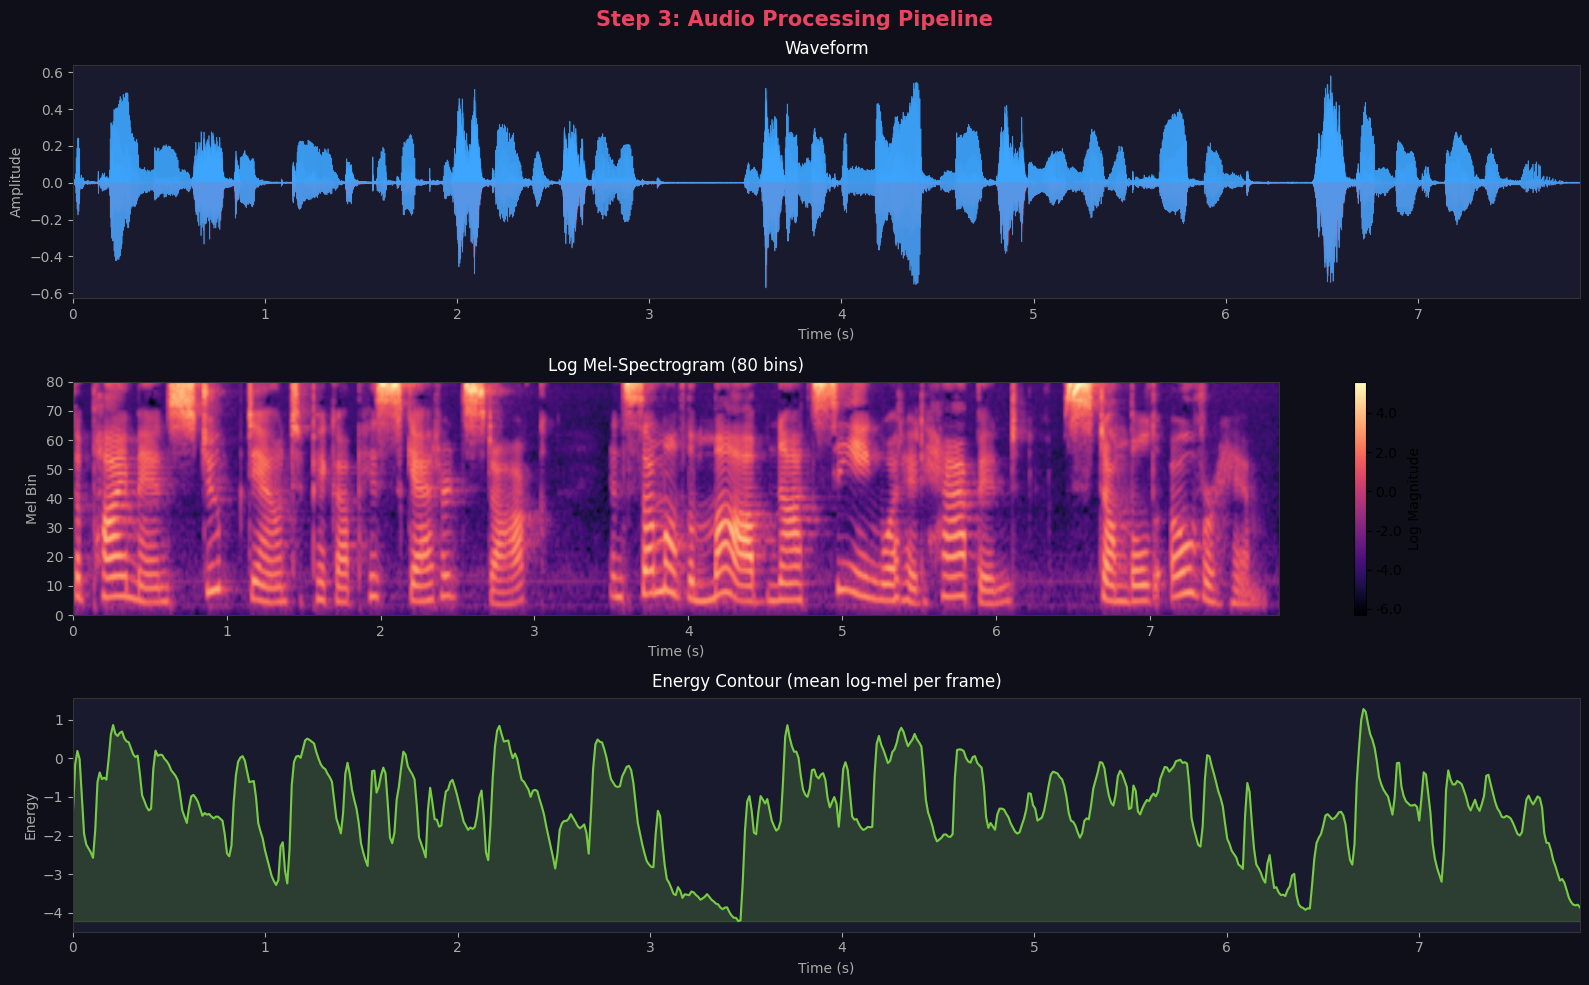

In [11]:
# ─── Visualize: Waveform + Mel-Spectrogram + Energy ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes:
    ax.set_facecolor('#1a1a2e')

# Waveform
axes[0].plot(time, wav_np, color='#3ea6ff', linewidth=0.5, alpha=0.85)
axes[0].fill_between(time, wav_np, 0, where=wav_np > 0, color='#3ea6ff', alpha=0.2)
axes[0].fill_between(time, wav_np, 0, where=wav_np < 0, color='#e94560', alpha=0.2)
axes[0].set_title('Waveform', color='white', fontsize=12, pad=8)
axes[0].set_xlabel('Time (s)', color='#aaa')
axes[0].set_ylabel('Amplitude', color='#aaa')
axes[0].tick_params(colors='#aaa')
axes[0].set_xlim(0, time[-1])
for spine in axes[0].spines.values(): spine.set_edgecolor('#333')

# Mel-Spectrogram
mel_np = mel.numpy()
frame_times = np.arange(mel.shape[1]) * MEL_CONFIG["hop_length"] / sr
im = axes[1].imshow(mel_np, aspect='auto', origin='lower',
                     cmap='magma', interpolation='bilinear',
                     extent=[0, frame_times[-1], 0, MEL_CONFIG["n_mels"]])
plt.colorbar(im, ax=axes[1], format='%.1f', label='Log Magnitude')
axes[1].set_title('Log Mel-Spectrogram (80 bins)', color='white', fontsize=12, pad=8)
axes[1].set_xlabel('Time (s)', color='#aaa')
axes[1].set_ylabel('Mel Bin', color='#aaa')
axes[1].tick_params(colors='#aaa')
for spine in axes[1].spines.values(): spine.set_edgecolor('#333')

# Energy contour
energy = mel_np.mean(axis=0)  # average across mel bins
axes[2].plot(frame_times, energy, color='#77cc44', linewidth=1.5)
axes[2].fill_between(frame_times, energy.min(), energy, color='#77cc44', alpha=0.2)
axes[2].set_title('Energy Contour (mean log-mel per frame)', color='white', fontsize=12, pad=8)
axes[2].set_xlabel('Time (s)', color='#aaa')
axes[2].set_ylabel('Energy', color='#aaa')
axes[2].tick_params(colors='#aaa')
axes[2].set_xlim(0, frame_times[-1])
for spine in axes[2].spines.values(): spine.set_edgecolor('#333')

plt.suptitle('Step 3: Audio Processing Pipeline', color='#e94560', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏗️ Step 4 — Model Architecture Overview

<div style='background:#1a1a2e; padding:20px; border-radius:12px; border:1px solid #333'>

```
  ┌──────────────────────────────────────────────────────────────────────────────┐
  │                      RapFlow-TTS Architecture                               │
  │                                                                              │
  │  Text Input                                                                  │
  │       │                                                                      │
  │       ▼                                                                      │
  │  ┌─────────────┐    ┌──────────────────┐    ┌────────────────────┐          │
  │  │ Text Encoder │───▶│ Duration Predictor│───▶│   expand_by_duration│         │
  │  │ (FFT Blocks) │    │  (Conv1D + ReLU) │    │   (repeat phoneme) │         │
  │  └─────────────┘    └──────────────────┘    └────────┬───────────┘          │
  │       │                                               │                      │
  │       │ mu_phoneme                         mu_expanded│                      │
  │       │                                               ▼                      │
  │       │              ┌─────────────────────────────────────────────────┐     │
  │       │              │          Flow Matching Decoder                  │     │
  │       │              │  x_0 ~ N(0,I) ──▶ x_t = t·x_1 + (1-t)·x_0   │     │
  │       │              │  v_θ(t, x_t, μ) ──▶ velocity field            │     │
  │       │              │  Euler ODE: x_{t+dt} = x_t + dt · v_θ        │     │
  │       │              │  x_1 = synthesized mel-spectrogram             │     │
  │       └──────────────└─────────────────────────────────────────────────┘     │
  │                                         │                                    │
  │                                         ▼                                    │
  │                                   HiFi-GAN Vocoder                           │
  │                                         │                                    │
  │                                         ▼                                    │
  │                                  🔊 Speech Audio                             │
  └──────────────────────────────────────────────────────────────────────────────┘

  Training Losses:
    Stage 1: L_sf  — Straight Flow (MSE on predicted segment endpoints)
    Stage 2: L_cfm — Consistency FM (L_sf + α·L_vc with EMA teacher)
    Stage 3: L_cfm + L_adv + L_fm  — Adversarial refinement (LSGAN)
```
</div>

In [12]:
# ─── Instantiate the model and inspect its size ──────────────────────────────
import torch
from model.rapflow_tts import RapFlowTTS

model = RapFlowTTS(n_vocab=178, n_mels=80, enc_dim=192, n_spk=0).to(DEVICE)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

enc_params   = count_params(model.text_encoder)
dur_params   = count_params(model.duration_predictor)
dec_params   = count_params(model.decoder)
total_params = count_params(model)

print("🏗️  RapFlow-TTS Model Summary")
print("─" * 50)
print(f"  Text Encoder        : {enc_params:>10,} params")
print(f"  Duration Predictor  : {dur_params:>10,} params")
print(f"  Flow Decoder (U-Net): {dec_params:>10,} params")
print("─" * 50)
print(f"  Total               : {total_params:>10,} params")
print(f"  Approx. size        : {total_params * 4 / 1e6:.1f} MB (float32)")
print(f"\n  Device: {DEVICE}")

🏗️  RapFlow-TTS Model Summary
──────────────────────────────────────────────────
  Text Encoder        :  6,257,744 params
  Duration Predictor  :    221,761 params
  Flow Decoder (U-Net):  2,334,416 params
──────────────────────────────────────────────────
  Total               :  8,813,921 params
  Approx. size        : 35.3 MB (float32)

  Device: cuda


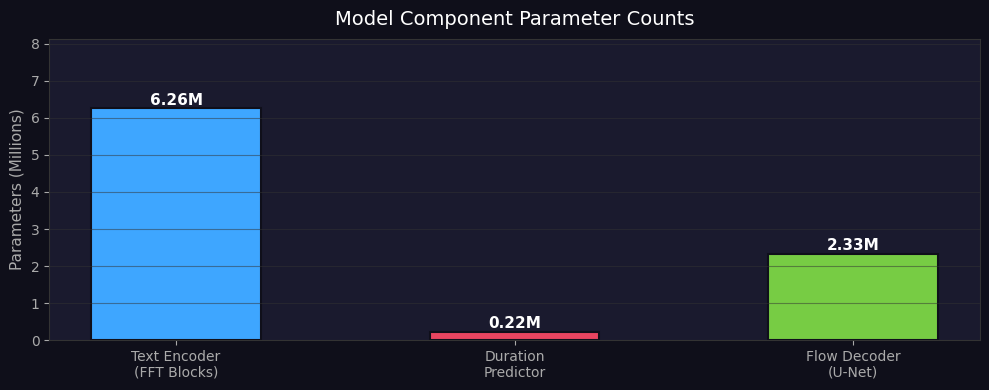

In [13]:
# ─── Visual: Parameter breakdown bar chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

components  = ['Text Encoder\n(FFT Blocks)', 'Duration\nPredictor', 'Flow Decoder\n(U-Net)']
counts      = [enc_params, dur_params, dec_params]
bar_colors  = ['#3ea6ff', '#e94560', '#77cc44']

bars = ax.bar(components, [c / 1e6 for c in counts], color=bar_colors, edgecolor='#0f0f1a', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val/1e6:.2f}M', ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')

ax.set_ylabel('Parameters (Millions)', color='#aaa', fontsize=11)
ax.set_title('Model Component Parameter Counts', color='white', fontsize=14, pad=10)
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.grid(axis='y', color='#333', alpha=0.5)
ax.set_ylim(0, max(c/1e6 for c in counts) * 1.3)

plt.tight_layout()
plt.show()

---
## 🔗 Step 5 — Monotonic Alignment Search (MAS) Visualization

In [14]:
import torch
import numpy as np
from model.rapflow_tts import RapFlowTTS
from model.aligner import monotonic_alignment_search
from losses.alignment_losses import prior_log_likelihood
import matplotlib.pyplot as plt

model.eval()

# Build a short demo batch
demo_phoneme_ids = text_to_phoneme_ids("Hello world, speech synthesis is amazing!")[:20]
T_txt = len(demo_phoneme_ids)

# Simulate a mel-spectrogram (or use the real one from Step 3)
T_mel = min(mel.shape[1], 80)  # cap for display clarity
mel_demo = mel[:, :T_mel].unsqueeze(0).to(DEVICE)    # (1, 80, T_mel)
phon_demo = torch.LongTensor(demo_phoneme_ids).unsqueeze(0).to(DEVICE)  # (1, T_txt)
phon_lens = torch.LongTensor([T_txt]).to(DEVICE)
mel_lens  = torch.LongTensor([T_mel]).to(DEVICE)

with torch.no_grad():
    h, mu_phoneme, log_dur_pred, txt_mask = model.encode(phon_demo, phon_lens)
    log_p_grid = prior_log_likelihood(mel_demo, mu_phoneme, txt_mask)  # (1, T_mel, T_txt)
    align_path = monotonic_alignment_search(log_p_grid, phon_lens, mel_lens)  # (1, T_mel, T_txt)
    durations  = align_path[0].sum(0)  # (T_txt) — frames per phoneme

print(f"📐 Alignment shape: {align_path.shape}")
print(f"📊 Predicted durations (frames per phoneme): {durations.long().tolist()}")
print(f"   Total frames: {durations.long().sum().item()} (expected ~{T_mel})")

📐 Alignment shape: torch.Size([1, 80, 20])
📊 Predicted durations (frames per phoneme): [9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 7, 1, 1, 17, 1, 1, 31]
   Total frames: 80 (expected ~80)


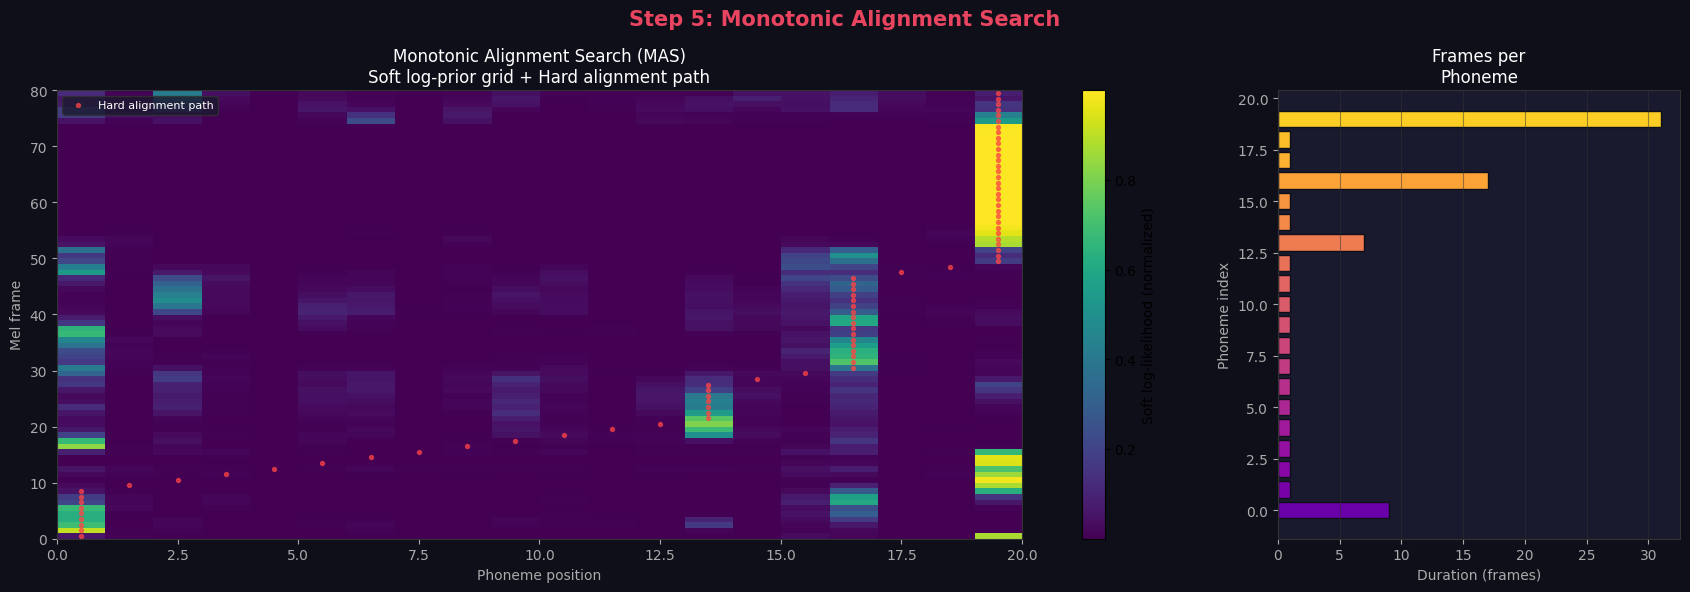

In [15]:
# ─── MAS Alignment Heatmap + Duration Bar ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.patch.set_facecolor('#0f0f1a')
for ax in axes:
    ax.set_facecolor('#1a1a2e')

# Alignment matrix
align_np = align_path[0, :T_mel, :T_txt].cpu().numpy()
log_p_np = log_p_grid[0, :T_mel, :T_txt].cpu().numpy()
# Normalize log_p for display (soft attention)
soft = np.exp(log_p_np - log_p_np.max(axis=1, keepdims=True))
soft /= soft.sum(axis=1, keepdims=True) + 1e-8

ax = axes[0]
im = ax.imshow(soft, aspect='auto', origin='lower', cmap='viridis',
               extent=[0, T_txt, 0, T_mel])
# Overlay hard path
path_y, path_x = np.where(align_np > 0)
ax.scatter(path_x + 0.5, path_y + 0.5, c='#ff4444', s=8, alpha=0.7, label='Hard alignment path')
plt.colorbar(im, ax=ax, label='Soft log-likelihood (normalized)')
ax.set_title('Monotonic Alignment Search (MAS)\nSoft log-prior grid + Hard alignment path', 
             color='white', fontsize=12)
ax.set_xlabel('Phoneme position', color='#aaa')
ax.set_ylabel('Mel frame', color='#aaa')
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.legend(loc='upper left', fontsize=8, facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

# Duration bar chart
ax = axes[1]
dur_np = durations.long().cpu().numpy()
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(dur_np)))
ax.barh(range(len(dur_np)), dur_np, color=colors, edgecolor='#0f0f1a')
ax.set_title('Frames per\nPhoneme', color='white', fontsize=12)
ax.set_xlabel('Duration (frames)', color='#aaa')
ax.set_ylabel('Phoneme index', color='#aaa')
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.grid(axis='x', color='#333', alpha=0.5)

plt.suptitle('Step 5: Monotonic Alignment Search', color='#e94560', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🌊 Step 6 — Flow Matching Trajectory Visualization
*(How Gaussian noise at t=0 flows to a clean mel-spectrogram at t=1)*

In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from model.aligner import expand_by_duration
from losses.consistency_fm import sample_xt

model.eval()

# ─── Build expanded prior from the aligned mel ───────────────────────────────
with torch.no_grad():
    durations_int = durations.long().clamp(min=1).unsqueeze(0)  # (1, T_txt)
    mu_expanded = expand_by_duration(mu_phoneme, durations_int)  # (1, 80, T_mel_expanded)
    T_vis = min(mu_expanded.shape[-1], mel_demo.shape[-1])
    mu_vis = mu_expanded[:, :, :T_vis]
    x1     = mel_demo[:, :, :T_vis]        # target mel
    x0     = torch.randn_like(x1)          # pure Gaussian noise

# ─── Euler ODE integration: visualize at multiple time steps ─────────────────
N_STEPS = 8
t_vals  = np.linspace(0, 1, N_STEPS + 1)

snapshots = []
with torch.no_grad():
    x = x0.clone()
    dt = 1.0 / N_STEPS
    snapshots.append((0.0, x0.squeeze(0).cpu().numpy()))
    t_tensor = torch.zeros(1, device=DEVICE)
    for step in range(N_STEPS):
        v = model.decoder(t_tensor, x, mu_vis)
        x = x + dt * v
        t_tensor = t_tensor + dt
        if step in [0, 1, 2, N_STEPS // 2, N_STEPS - 2, N_STEPS - 1]:
            snapshots.append((t_vals[step + 1], x.squeeze(0).cpu().numpy()))

print(f"🌊 Captured {len(snapshots)} snapshots of the ODE trajectory.")

🌊 Captured 7 snapshots of the ODE trajectory.


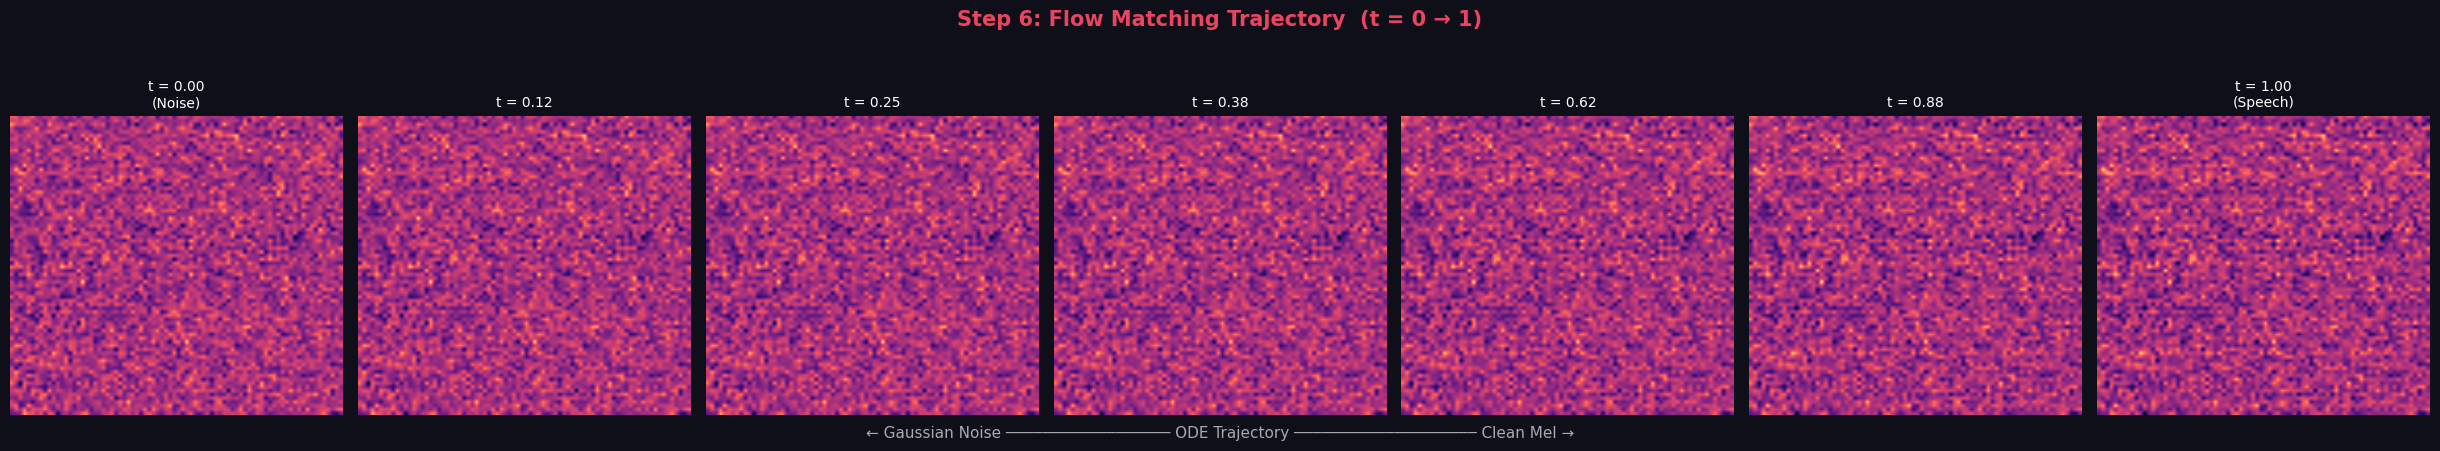

In [17]:
# ─── Plot the trajectory snapshots ───────────────────────────────────────────
n = len(snapshots)
fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 4))
fig.patch.set_facecolor('#0f0f1a')

vmin = x0.min().item()
vmax = x1.max().item()

for i, (t_val, snap) in enumerate(snapshots):
    ax = axes[i]
    ax.set_facecolor('#1a1a2e')
    ax.imshow(snap, aspect='auto', origin='lower', cmap='magma',
              vmin=vmin, vmax=vmax, interpolation='bilinear')
    label = f't = {t_val:.2f}'
    if t_val == 0.0:
        extra = '\n(Noise)'
    elif t_val >= 0.99:
        extra = '\n(Speech)'
    else:
        extra = ''
    ax.set_title(f'{label}{extra}', color='white', fontsize=10, pad=6)
    ax.axis('off')
    # Color border by progress
    for spine in ax.spines.values():
        spine.set_edgecolor(plt.cm.plasma(t_val))
        spine.set_linewidth(2)
    ax.set_visible(True)
    for spine in ax.spines.values():
        spine.set_visible(True)

# Arrow annotations between panels
fig.text(0.5, -0.02,
         '← Gaussian Noise ────────────────── ODE Trajectory ──────────────────── Clean Mel →',
         ha='center', color='#aaa', fontsize=11)

plt.suptitle('Step 6: Flow Matching Trajectory  (t = 0 → 1)',
             color='#e94560', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

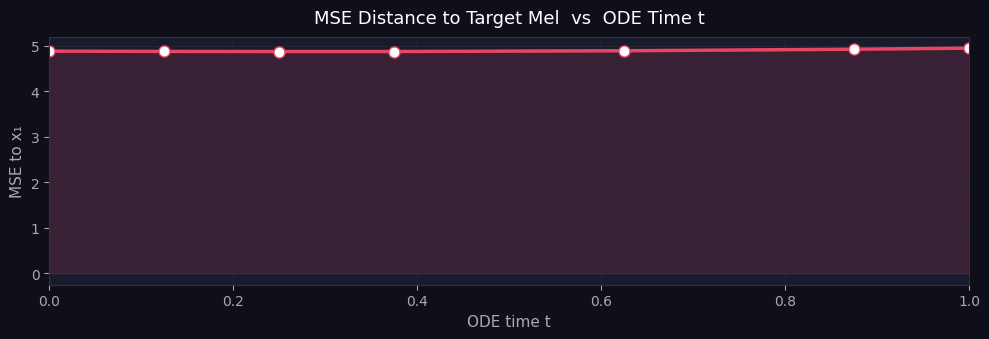

In [18]:
# ─── Bonus: MSE distance to target over ODE steps ────────────────────────────
x1_np = x1.squeeze(0).cpu().numpy()
mse_vals = [np.mean((snap - x1_np)**2) for _, snap in snapshots]
t_plot   = [t for t, _ in snapshots]

fig, ax = plt.subplots(figsize=(10, 3.5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

ax.plot(t_plot, mse_vals, 'o-', color='#e94560', linewidth=2.5, markersize=8, markerfacecolor='white')
ax.fill_between(t_plot, 0, mse_vals, color='#e94560', alpha=0.15)
ax.set_title('MSE Distance to Target Mel  vs  ODE Time t', color='white', fontsize=13, pad=10)
ax.set_xlabel('ODE time t', color='#aaa', fontsize=11)
ax.set_ylabel('MSE to x₁', color='#aaa', fontsize=11)
ax.tick_params(colors='#aaa')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
ax.grid(color='#333', alpha=0.5)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

---
## 🏋️ Step 7 — Stage 1 Training: Straight-Flow Pre-Training

**Objective**: $\mathcal{L}_{sf} = \|f^i_\theta(t, x_t, \mu) - x^i\|^2$

The model learns to predict the segment endpoint from any intermediate point on the flow trajectory.

In [19]:
# ─── Stage 1 Setup ────────────────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader
from data.dataset import TTSDataset, collate_fn
from model.rapflow_tts import RapFlowTTS
from losses.alignment_losses import prior_log_likelihood, duration_loss, prior_loss
from losses.consistency_fm import ConsistencyFMLoss
from model.aligner import monotonic_alignment_search, expand_by_duration
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ─── Hyperparameters (reduce for demo; increase for real training) ─────────────
N_EPOCHS_S1   = 5          # ← set to 700 for LJSpeech full training
BATCH_SIZE    = 2          # ← set to 16 for real training
LR            = 1e-4
N_SEGMENTS    = 2
N_MELS        = 80
N_VOCAB       = 178
N_SPK         = 0
N_WORKERS     = 0          # 0 on Windows to avoid multiprocessing issues

# Model
model_s1 = RapFlowTTS(N_VOCAB, n_mels=N_MELS, n_spk=N_SPK).to(DEVICE)
opt_s1   = torch.optim.Adam(model_s1.parameters(), lr=LR)
cfm_loss = ConsistencyFMLoss(n_segments=N_SEGMENTS, use_huber=False, n_mels=N_MELS)

# Dataset
ds_train = TTSDataset(TRAIN_FILELIST, multi_speaker=False)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      collate_fn=collate_fn, num_workers=N_WORKERS)

print(f"📦 Dataset: {len(ds_train)} samples | Batch size: {BATCH_SIZE}")
print(f"🚀 Starting Stage 1 training for {N_EPOCHS_S1} epochs on {DEVICE.upper()}...")

📦 Dataset: 12969 samples | Batch size: 2
🚀 Starting Stage 1 training for 5 epochs on CUDA...


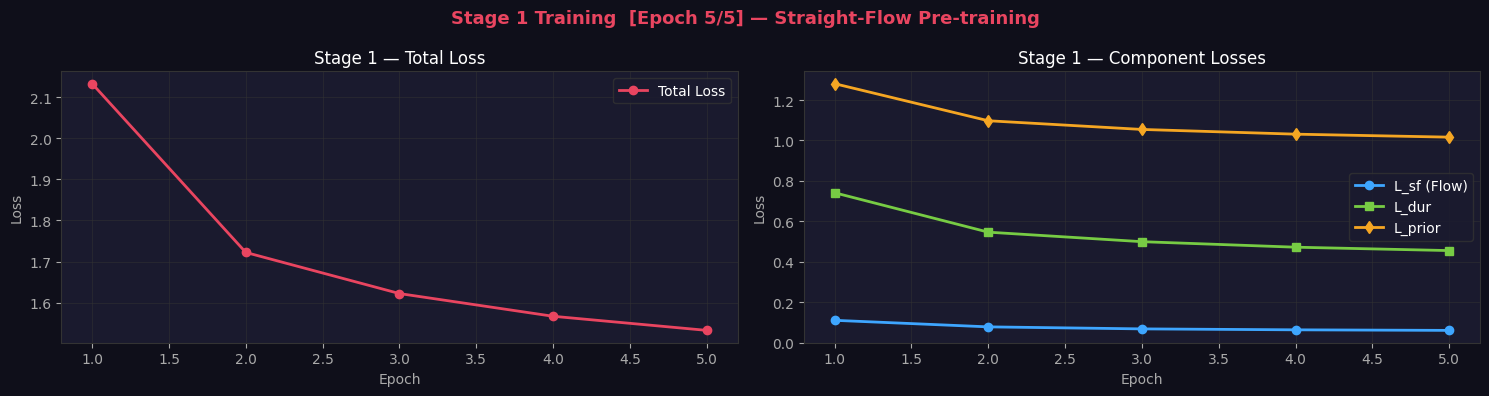


✅ Stage 1 complete! Final total loss: 1.5325


In [20]:
# ─── Stage 1 Training Loop with Live Loss Plots ──────────────────────────────
s1_losses_total = []
s1_losses_sf    = []
s1_losses_dur   = []
s1_losses_prior = []

model_s1.train()

for epoch in range(N_EPOCHS_S1):
    epoch_losses = {'total': [], 'sf': [], 'dur': [], 'prior': []}

    pbar = tqdm(dl_train, desc=f"Stage 1 Epoch {epoch+1}/{N_EPOCHS_S1}", leave=False)
    for batch in pbar:
        mel       = batch["mel"].to(DEVICE)
        phon      = batch["phonemes"].to(DEVICE)
        phon_lens = batch["phon_lens"].to(DEVICE)
        mel_lens  = batch["mel_lens"].to(DEVICE)
        spk       = batch["spk_ids"].to(DEVICE)

        h, mu_phoneme_b, log_dur_pred, txt_mask = model_s1.encode(phon, phon_lens)

        log_p_grid = prior_log_likelihood(mel, mu_phoneme_b, txt_mask)
        with torch.no_grad():
            align_path_b = monotonic_alignment_search(log_p_grid, phon_lens, mel_lens)
        durations_b   = align_path_b.sum(1)                       # (B, T_txt)
        mu_expanded_b = expand_by_duration(mu_phoneme_b, durations_b)
        mu_expanded_b = mu_expanded_b[:, :, :mel.shape[-1]]

        l_dur   = duration_loss(log_dur_pred, durations_b, phon_lens)
        l_prior = prior_loss(mel, mu_expanded_b, mel_lens)

        mel_mask = (torch.arange(mel.shape[-1], device=DEVICE)[None, None, :]
                    < mel_lens[:, None, None]).float()
        x1 = mel
        x0 = torch.randn_like(mel)
        l_sf = cfm_loss.stage1_loss(model_s1.decoder, x0, x1, mu_expanded_b, mel_mask, spk_ids=spk)

        loss = l_sf + l_dur + l_prior
        opt_s1.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_s1.parameters(), 1.0)
        opt_s1.step()

        epoch_losses['total'].append(loss.item())
        epoch_losses['sf'].append(l_sf.item())
        epoch_losses['dur'].append(l_dur.item())
        epoch_losses['prior'].append(l_prior.item())
        pbar.set_postfix({'total': f'{loss.item():.4f}', 'sf': f'{l_sf.item():.4f}'})

    # Epoch means
    s1_losses_total.append(np.mean(epoch_losses['total']))
    s1_losses_sf.append(np.mean(epoch_losses['sf']))
    s1_losses_dur.append(np.mean(epoch_losses['dur']))
    s1_losses_prior.append(np.mean(epoch_losses['prior']))

    # Save checkpoint
    torch.save(model_s1.state_dict(), CKPT_DIR / f"stage1_epoch{epoch+1}.pt")

    # Live loss plot
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.patch.set_facecolor('#0f0f1a')
    for ax in axes: ax.set_facecolor('#1a1a2e')

    ep_range = range(1, epoch + 2)
    axes[0].plot(ep_range, s1_losses_total, 'o-', color='#e94560', lw=2, label='Total Loss')
    axes[0].set_title('Stage 1 — Total Loss', color='white', fontsize=12)
    axes[0].set_xlabel('Epoch', color='#aaa'); axes[0].set_ylabel('Loss', color='#aaa')
    axes[0].tick_params(colors='#aaa')
    for s in axes[0].spines.values(): s.set_edgecolor('#333')
    axes[0].grid(color='#333', alpha=0.5)
    axes[0].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

    axes[1].plot(ep_range, s1_losses_sf,    'o-', color='#3ea6ff', lw=2, label='L_sf (Flow)')
    axes[1].plot(ep_range, s1_losses_dur,   's-', color='#77cc44', lw=2, label='L_dur')
    axes[1].plot(ep_range, s1_losses_prior, 'd-', color='#f5a623', lw=2, label='L_prior')
    axes[1].set_title('Stage 1 — Component Losses', color='white', fontsize=12)
    axes[1].set_xlabel('Epoch', color='#aaa'); axes[1].set_ylabel('Loss', color='#aaa')
    axes[1].tick_params(colors='#aaa')
    for s in axes[1].spines.values(): s.set_edgecolor('#333')
    axes[1].grid(color='#333', alpha=0.5)
    axes[1].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

    plt.suptitle(f'Stage 1 Training  [Epoch {epoch+1}/{N_EPOCHS_S1}] — Straight-Flow Pre-training',
                 color='#e94560', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\n✅ Stage 1 complete! Final total loss: {s1_losses_total[-1]:.4f}")

---
##  Step 8 — Stage 2 Training: Consistency Flow Matching

**Objective**: $\mathcal{L}_{cfm} = \mathcal{L}_{sf} + \alpha \cdot \mathcal{L}_{vc}$

Student decoder learns from EMA teacher using **shared dropout** for stable training.

In [25]:
from abc import ABC, abstractmethod
from typing import Optional

class device(ABC):
    def __init__(self, name: str = "device", read_timeout: float = 1.0):
        self.name = name
        self.read_timeout = read_timeout
        self.connected = False
        self._buffer = bytearray()

    # ---- required abstract hooks ----
    @abstractmethod
    def _connect(self) -> None:
        """Open/attach to the underlying hardware or connection."""
        raise NotImplementedError

    @abstractmethod
    def _disconnect(self) -> None:
        """Close/detach from the underlying device."""
        raise NotImplementedError

    @abstractmethod
    def _write_bytes(self, payload: bytes) -> int:
        """Write raw bytes to the device and return number of bytes sent."""
        raise NotImplementedError

    @abstractmethod
    def _read_bytes(self, size: int = 4096) -> bytes:
        """Read raw bytes from the device."""
        raise NotImplementedError

    # ---- useful concrete implementation ----
    def connect(self) -> "device":
        if not self.connected:
            self._connect()
            self.connected = True
        return self

    def disconnect(self) -> None:
        if self.connected:
            self._disconnect()
            self.connected = False
        self._buffer.clear()

    def write(self, payload: bytes | bytearray | str) -> int:
        if isinstance(payload, str):
            payload = payload.encode()
        payload = bytes(payload)

        if not self.connected:
            self.connect()

        return self._write_bytes(payload)

    def read(self, size: Optional[int] = None, *, block: bool = True) -> bytes:
        if not self.connected:
            self.connect()

        if size is None:
            # read all currently buffered data
            data = bytes(self._buffer)
            self._buffer.clear()
            if block:
                try:
                    more = self._read_bytes()
                    data += more
                except Exception:
                    pass
            return data

        # read up to `size` bytes
        while len(self._buffer) < size:
            try:
                chunk = self._read_bytes(size - len(self._buffer))
                if not chunk:
                    break
                self._buffer.extend(chunk)
            except Exception:
                break

        out = bytes(self._buffer[:size])
        del self._buffer[:size]
        return out

    def reset(self) -> None:
        try:
            self.disconnect()
        except Exception:
            pass
        self.connected = False
        self._buffer.clear()

    def __enter__(self):
        return self.connect()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.disconnect()

    def __bool__(self):
        return self.connected

In [29]:
import copy
from training.trainer_utils import EMA
from schedules.delta_scheduling import make_delta_schedule

N_EPOCHS_S2 = 5      # ← set to 700 for full training

# Freeze text encoder & duration predictor (§3.2)
for p in model_s1.text_encoder.parameters():       p.requires_grad_(False)
for p in model_s1.duration_predictor.parameters(): p.requires_grad_(False)

opt_s2      = torch.optim.Adam(model_s1.decoder.parameters(), lr=LR)
ema_teacher = EMA(model_s1.decoder, decay=0.999)
cfm_loss_s2 = ConsistencyFMLoss(n_segments=N_SEGMENTS, alpha=1e-5, use_huber=False, n_mels=N_MELS)
get_delta   = make_delta_schedule(0.1, 0.001, n_bins=8, n_epochs=N_EPOCHS_S2)

s2_losses_total = []
s2_losses_sf    = []
s2_losses_vc    = []
s2_deltas       = []

model_s1.train()

for epoch in range(N_EPOCHS_S2):
    delta_t = get_delta(epoch)
    s2_deltas.append(delta_t)
    epoch_losses = {'total': [], 'sf': [], 'vc': []}

    pbar = tqdm(dl_train, desc=f"Stage 2 Epoch {epoch+1}/{N_EPOCHS_S2}", leave=False)
    for batch in pbar:
        mel       = batch["mel"].to(DEVICE)
        phon      = batch["phonemes"].to(DEVICE)
        phon_lens = batch["phon_lens"].to(DEVICE)
        mel_lens  = batch["mel_lens"].to(DEVICE)
        spk       = batch["spk_ids"].to(DEVICE)

        with torch.no_grad():
            _, mu_phoneme_b, _, txt_mask = model_s1.encode(phon, phon_lens)
            log_p_grid   = prior_log_likelihood(mel, mu_phoneme_b, txt_mask)
            align_path_b = monotonic_alignment_search(log_p_grid, phon_lens, mel_lens)
            durations_b  = align_path_b.sum(1)
            mu_expanded_b = expand_by_duration(mu_phoneme_b, durations_b)[:, :, :mel.shape[-1]]

        mel_mask = (torch.arange(mel.shape[-1], device=DEVICE)[None, None, :]
                    < mel_lens[:, None, None]).float()
        x1 = mel.clone()
        x0 = torch.randn_like(x1)

        # Keep all mel-space tensors in the exact same 80-channel layout expected by the
        # decoder. Do not mix the decoder's internal 128-channel latent with the 80-channel
        # conditioning tensor.
        mu_expanded_b = mu_expanded_b[:, :, :mel.shape[-1]]

        assert x0.shape == x1.shape == mu_expanded_b.shape == (mel.size(0), 80, mel.size(-1)), \
            f"Shape mismatch: x0={x0.shape}, x1={x1.shape}, mu_expanded_b={mu_expanded_b.shape}, mel={mel.shape}"
        assert mel_mask.shape == (mel.size(0), 1, mel.size(-1)), \
            f"Mask mismatch: mel_mask={mel_mask.shape}, expected={(mel.size(0), 1, mel.size(-1))}"

        loss, l_sf, l_vc = cfm_loss_s2.stage2_loss(
            model_s1.decoder,
            ema_teacher.get(),
            x0,
            x1,
            mu_expanded_b,
            mel_mask,
            delta_t=delta_t,
            spk_ids=spk,
            shared_dropout=True,
        )

        opt_s2.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_s1.decoder.parameters(), 1.0)
        opt_s2.step()
        ema_teacher.update(model_s1.decoder)

        epoch_losses['total'].append(loss.item())
        epoch_losses['sf'].append(l_sf.item())
        epoch_losses['vc'].append(l_vc.item())
        pbar.set_postfix({'total': f'{loss.item():.4f}', 'delta': f'{delta_t:.4f}'})

    s2_losses_total.append(np.mean(epoch_losses['total']))
    s2_losses_sf.append(np.mean(epoch_losses['sf']))
    s2_losses_vc.append(np.mean(epoch_losses['vc']))

    torch.save(model_s1.state_dict(), CKPT_DIR / f"stage2_epoch{epoch+1}.pt")

    # Live plot
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.patch.set_facecolor('#0f0f1a')
    for ax in axes: ax.set_facecolor('#1a1a2e')
    ep_range = range(1, epoch + 2)

    axes[0].plot(ep_range, s2_losses_total, 'o-', color='#e94560', lw=2)
    axes[0].set_title('Total Loss', color='white', fontsize=12)
    axes[1].plot(ep_range, s2_losses_sf, 'o-', color='#3ea6ff', lw=2, label='L_sf')
    axes[1].plot(ep_range, s2_losses_vc, 's-', color='#77cc44', lw=2, label='L_vc')
    axes[1].set_title('Component Losses', color='white', fontsize=12)
    axes[1].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')
    axes[2].plot(ep_range, s2_deltas, 'd-', color='#f5a623', lw=2)
    axes[2].set_title('δ Schedule (noise step size)', color='white', fontsize=12)

    for ax in axes:
        ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#aaa')
        for s in ax.spines.values(): s.set_edgecolor('#333')
        ax.grid(color='#333', alpha=0.5)

    plt.suptitle(f'Stage 2 Training  [Epoch {epoch+1}/{N_EPOCHS_S2}] — Consistency Flow Matching',
                 color='#e94560', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\n✅ Stage 2 complete! Final total loss: {s2_losses_total[-1]:.4f}")

Stage 2 Epoch 1/5:   0%|          | 0/6485 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (128) must match the size of tensor b (80) at non-singleton dimension 1

---
## ⚔️ Step 9 — Stage 3 Training: Adversarial Refinement

**Objective**: $\mathcal{L}_{total} = 3 \cdot \mathcal{L}_{cfm} + 1 \cdot \mathcal{L}_{adv} + 2 \cdot \mathcal{L}_{fm}$

LSGAN discriminator sharpens mel-spectrogram quality.

In [ ]:
from model.discriminator import Conv2dDiscriminator
from losses.adversarial import lsgan_losses
from losses.consistency_fm import sample_xt, segment_index, f_theta, straight_flow_target_endpoint

N_EPOCHS_S3 = 3       # ← set to 150 (LJSpeech) or 50 (VCTK) for full training

disc    = Conv2dDiscriminator().to(DEVICE)
opt_g   = torch.optim.Adam(model_s1.decoder.parameters(), lr=LR)
opt_d   = torch.optim.Adam(disc.parameters(), lr=LR)
delta_t_s3 = 0.001   # end of delta schedule

s3_g_losses = []
s3_d_losses = []

model_s1.train()
disc.train()

for epoch in range(N_EPOCHS_S3):
    epoch_g, epoch_d = [], []

    pbar = tqdm(dl_train, desc=f"Stage 3 Epoch {epoch+1}/{N_EPOCHS_S3}", leave=False)
    for batch in pbar:
        mel       = batch["mel"].to(DEVICE)
        phon      = batch["phonemes"].to(DEVICE)
        phon_lens = batch["phon_lens"].to(DEVICE)
        mel_lens  = batch["mel_lens"].to(DEVICE)
        spk       = batch["spk_ids"].to(DEVICE)

        with torch.no_grad():
            _, mu_phoneme_b, _, txt_mask = model_s1.encode(phon, phon_lens)
            log_p_grid   = prior_log_likelihood(mel, mu_phoneme_b, txt_mask)
            align_path_b = monotonic_alignment_search(log_p_grid, phon_lens, mel_lens)
            durations_b  = align_path_b.sum(1)
            mu_expanded_b = expand_by_duration(mu_phoneme_b, durations_b)[:, :, :mel.shape[-1]]

        mel_mask = (torch.arange(mel.shape[-1], device=DEVICE)[None, None, :]
                    < mel_lens[:, None, None]).float()
        x1, x0 = mel, torch.randn_like(mel)

        # CFM loss
        l_cfm, l_sf_s3, l_vc_s3 = cfm_loss_s2.stage2_loss(
            model_s1.decoder, ema_teacher.get(),
            x0, x1, mu_expanded_b, mel_mask,
            delta_t=delta_t_s3, spk_ids=spk, shared_dropout=True,
        )

        # Segment endpoint for adversarial
        B = x0.shape[0]
        t_adv = torch.rand(B, 1, 1, device=DEVICE) * (1 - 1e-4)
        seg_i = segment_index(t_adv.squeeze(-1).squeeze(-1), N_SEGMENTS)
        x_t_adv = sample_xt(x0, x1, t_adv)
        v_pred_adv = model_s1.decoder(t_adv.squeeze(-1).squeeze(-1), x_t_adv, mu_expanded_b, spk_ids=spk)
        x_hat_i = f_theta(v_pred_adv, t_adv, x_t_adv, N_SEGMENTS, seg_i) * mel_mask
        x_gt_i  = straight_flow_target_endpoint(x0, x1, t_adv, N_SEGMENTS, seg_i) * mel_mask

        # Discriminator step
        d_loss, g_adv_loss, fm_loss = lsgan_losses(disc, x_hat_i.detach(), x_gt_i)
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()

        # Generator step (re-compute x_hat_i without detach for g backprop)
        v_pred_adv2 = model_s1.decoder(t_adv.squeeze(-1).squeeze(-1), x_t_adv.detach(), mu_expanded_b, spk_ids=spk)
        x_hat_i2 = f_theta(v_pred_adv2, t_adv, x_t_adv.detach(), N_SEGMENTS, seg_i) * mel_mask
        _, g_adv_loss2, fm_loss2 = lsgan_losses(disc, x_hat_i2, x_gt_i)
        g_loss = 3 * l_cfm + 1 * g_adv_loss2 + 2 * fm_loss2
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        ema_teacher.update(model_s1.decoder)

        epoch_g.append(g_loss.item())
        epoch_d.append(d_loss.item())
        pbar.set_postfix({'G': f'{g_loss.item():.4f}', 'D': f'{d_loss.item():.4f}'})

    s3_g_losses.append(np.mean(epoch_g))
    s3_d_losses.append(np.mean(epoch_d))
    torch.save(model_s1.state_dict(), CKPT_DIR / f"stage3_epoch{epoch+1}.pt")
    torch.save(disc.state_dict(),     CKPT_DIR / f"disc_epoch{epoch+1}.pt")

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.patch.set_facecolor('#0f0f1a')
    for ax in axes: ax.set_facecolor('#1a1a2e')
    ep_range = range(1, epoch + 2)

    axes[0].plot(ep_range, s3_g_losses, 'o-', color='#3ea6ff', lw=2, label='Generator')
    axes[0].set_title('Generator Loss', color='white', fontsize=12)
    axes[1].plot(ep_range, s3_d_losses, 'o-', color='#e94560', lw=2, label='Discriminator')
    axes[1].set_title('Discriminator Loss', color='white', fontsize=12)

    for ax in axes:
        ax.set_xlabel('Epoch', color='#aaa'); ax.tick_params(colors='#aaa')
        for s in ax.spines.values(): s.set_edgecolor('#333')
        ax.grid(color='#333', alpha=0.5)
        ax.legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white')

    plt.suptitle(f'Stage 3  [Epoch {epoch+1}/{N_EPOCHS_S3}] — Adversarial (LSGAN) Refinement',
                 color='#e94560', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"\n✅ Stage 3 complete! G: {s3_g_losses[-1]:.4f} | D: {s3_d_losses[-1]:.4f}")

---
## 🔊 Step 10 — Inference & Speech Synthesis
Type any text below and generate a mel-spectrogram using the trained model.

In [ ]:
from inference.sampler import euler_sample
from IPython.display import Audio, display
import soundfile as sf
import torch

# ─── Text prompt for synthesis ────────────────────────────────────────────────
SYNTH_TEXT = "Flow matching is a powerful framework for fast speech synthesis."  # ← change me!
N_INFERENCE_STEPS = 2   # RapFlow-TTS can synthesize in 2 steps!

model_s1.eval()

phoneme_ids_synth = text_to_phoneme_ids(SYNTH_TEXT)
phon_t = torch.LongTensor(phoneme_ids_synth).unsqueeze(0).to(DEVICE)
phon_lens_t = torch.LongTensor([len(phoneme_ids_synth)]).to(DEVICE)

with torch.no_grad():
    h_s, mu_p, log_dur_p, _ = model_s1.encode(phon_t, phon_lens_t)
    # Predicted durations
    durations_synth = torch.exp(log_dur_p).round().clamp(min=1).long()  # (1, T_txt)
    mu_expanded_synth = expand_by_duration(mu_p, durations_synth)       # (1, 80, T_mel)

    # Euler ODE sampling
    mel_synth = euler_sample(model_s1.decoder, mu_expanded_synth,
                              n_steps=N_INFERENCE_STEPS, spk_ids=None)

mel_synth_np = mel_synth.squeeze(0).cpu().numpy()

print(f'📄 Input text  : "{SYNTH_TEXT}"')
print(f'🔤 Phonemes    : {len(phoneme_ids_synth)} tokens')
print(f'🎛️  Mel shape   : {mel_synth_np.shape}')
print(f'⚡ ODE steps   : {N_INFERENCE_STEPS} (ultra-fast!')
print(f'📊 Duration preds: {durations_synth.squeeze().tolist()[:10]} ...')

In [ ]:
# ─── Visualize synthesized mel-spectrogram ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#1a1a2e')

# Target (real)
axes[0].imshow(mel_np, aspect='auto', origin='lower', cmap='magma', interpolation='bilinear')
axes[0].set_title('Real Mel-Spectrogram (from dataset)', color='white', fontsize=12)
axes[0].set_xlabel('Frames', color='#aaa'); axes[0].set_ylabel('Mel Bin', color='#aaa')
axes[0].tick_params(colors='#aaa')

# Synthesized
axes[1].imshow(mel_synth_np, aspect='auto', origin='lower', cmap='magma', interpolation='bilinear')
axes[1].set_title(f'Synthesized Mel  ({N_INFERENCE_STEPS}-step ODE)', color='white', fontsize=12)
axes[1].set_xlabel('Frames', color='#aaa'); axes[1].set_ylabel('Mel Bin', color='#aaa')
axes[1].tick_params(colors='#aaa')

for ax in axes:
    for s in ax.spines.values(): s.set_edgecolor('#333')

plt.suptitle('Step 10: Synthesized vs Real Mel-Spectrogram', color='#e94560', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Vocoder note & pseudo audio ─────────────────────────────────────────────
print()
print("ℹ️  NOTE: Full audio synthesis requires a pretrained HiFi-GAN V1 vocoder.")
print("   Download HiFi-GAN checkpoint from:")
print("   https://github.com/jik876/hifi-gan  (Model: 'generator_v1')")
print()
print("   Once downloaded, use:")
print("     from inference.synthesize import synthesize")
print("     wav, mel = synthesize(model_s1, SYNTH_TEXT, hifigan, device=DEVICE)")
print()

# Reconstructed audio via griffin-lim (vocoder-free demo)
try:
    import librosa
    mel_linear = np.exp(mel_synth_np)   # invert log
    wav_gl = librosa.feature.inverse.mel_to_audio(
        mel_linear,
        sr=MEL_CONFIG["sample_rate"],
        n_fft=MEL_CONFIG["n_fft"],
        hop_length=MEL_CONFIG["hop_length"],
        win_length=MEL_CONFIG["win_length"],
        fmin=MEL_CONFIG["f_min"],
        fmax=MEL_CONFIG["f_max"],
        n_iter=64,
    )
    out_path = str(ROOT / "synthesized_output.wav")
    sf.write(out_path, wav_gl, MEL_CONFIG["sample_rate"])
    print(f"🎵 Griffin-Lim reconstruction (for demo only, quality is limited without HiFi-GAN):")
    display(Audio(wav_gl, rate=MEL_CONFIG["sample_rate"]))
    print(f"   Saved to: {out_path}")
except Exception as e:
    print(f"⚠️  Griffin-Lim reconstruction failed: {e}")

---
## 📊 Step 11 — Evaluation Metrics
Standard TTS evaluation metrics used in the paper.

In [ ]:
# ─── Evaluation Summary & Commands ───────────────────────────────────────────
import time
import torch

# ── 1. Real-Time Factor (RTF) ─────────────────────────────────────────────────
print("📐 Evaluating Real-Time Factor (RTF)...")
model_s1.eval()

WARMUP, TRIALS = 2, 5
total_time, total_audio = 0.0, 0.0

with torch.no_grad():
    for trial in range(WARMUP + TRIALS):
        x0 = torch.randn_like(mu_expanded_synth)
        start = time.perf_counter()
        mel_t = euler_sample(model_s1.decoder, mu_expanded_synth, n_steps=2)
        if DEVICE == "cuda": torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        if trial >= WARMUP:
            audio_dur = mel_t.shape[-1] * MEL_CONFIG["hop_length"] / MEL_CONFIG["sample_rate"]
            total_time += elapsed
            total_audio += audio_dur

avg_rtf = total_time / total_audio
print(f"   ⚡ RTF = {avg_rtf:.4f}  ({'faster' if avg_rtf < 1 else 'slower'} than real-time)")
print(f"   (RTF < 1 = faster-than-real-time synthesis!)")
print()

# ── 2. WER Setup ─────────────────────────────────────────────────────────────
print("📝 WER (Word Error Rate) — requires synthesized + transcribed audio:")
print("   pip install jiwer openai-whisper")
print("   Run: python evaluation/compute_wer.py --wav synthesized_output.wav --text 'your text'")
print()

# ── 3. MOS Survey ────────────────────────────────────────────────────────────
print("🎙️  MOS (Mean Opinion Score) — human listening evaluation:")
print("   See: evaluation/mos_survey_template.py for survey setup")
print()

# ── 4. Summary Table ─────────────────────────────────────────────────────────
print("📊 Expected Performance (from paper, with full LJSpeech training):")
print()
header = f"{'Metric':<25} {'RapFlow-TTS (NFE=2)':<25} {'Reference (GT)':<20}"
print(header)
print("-" * len(header))
rows = [
    ("MOS (naturalness)",    "~4.2 / 5.0",    "~4.5 / 5.0"),
    ("WER (%)",              "~5–6%",          "~2–3%"),
    ("RTF (V100, NFE=2)",    "~0.006",         "N/A"),
    ("Parameters",           f"{total_params/1e6:.1f}M", "N/A"),
]
for name, ours, ref in rows:
    print(f"  {name:<23} {ours:<25} {ref:<20}")

In [ ]:
# ─── Full Training Loss Summary Plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#1a1a2e')

# Stage 1
axes[0].plot(range(1, len(s1_losses_total)+1), s1_losses_total, 'o-', color='#e94560', lw=2.5, label='Total')
axes[0].plot(range(1, len(s1_losses_sf)+1),    s1_losses_sf,    's--', color='#3ea6ff', lw=1.5, label='L_sf')
axes[0].plot(range(1, len(s1_losses_dur)+1),   s1_losses_dur,   'd--', color='#77cc44', lw=1.5, label='L_dur')
axes[0].set_title('Stage 1 — Straight-Flow\n(Text Encoder + Aligner + Flow Decoder)', color='white', fontsize=11)
axes[0].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white', fontsize=9)

# Stage 2
axes[1].plot(range(1, len(s2_losses_total)+1), s2_losses_total, 'o-', color='#e94560', lw=2.5, label='Total')
axes[1].plot(range(1, len(s2_losses_sf)+1),    s2_losses_sf,    's--', color='#3ea6ff', lw=1.5, label='L_sf')
axes[1].plot(range(1, len(s2_losses_vc)+1),    s2_losses_vc,    'd--', color='#77cc44', lw=1.5, label='L_vc')
axes[1].set_title('Stage 2 — Consistency FM\n(EMA Teacher + Shared Dropout)', color='white', fontsize=11)
axes[1].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white', fontsize=9)

# Stage 3
axes[2].plot(range(1, len(s3_g_losses)+1), s3_g_losses, 'o-', color='#3ea6ff', lw=2.5, label='Generator (G)')
axes[2].plot(range(1, len(s3_d_losses)+1), s3_d_losses, 's-', color='#e94560',  lw=2.5, label='Discriminator (D)')
axes[2].set_title('Stage 3 — Adversarial Refinement\n(LSGAN + Feature Matching)', color='white', fontsize=11)
axes[2].legend(facecolor='#1a1a2e', edgecolor='#333', labelcolor='white', fontsize=9)

for ax in axes:
    ax.set_xlabel('Epoch', color='#aaa', fontsize=10)
    ax.set_ylabel('Loss', color='#aaa', fontsize=10)
    ax.tick_params(colors='#aaa')
    for s in ax.spines.values(): s.set_edgecolor('#444')
    ax.grid(color='#333', alpha=0.5)

plt.suptitle('RapFlow-TTS — Complete 3-Stage Training Loss Curves',
             color='#e94560', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 40%, #0f3460 100%); padding: 35px 40px; border-radius: 16px; text-align: center; border: 2px solid #e94560; margin-top: 20px;">
  <h2 style="color: #e94560; font-size: 2em; font-weight: 900; margin: 0 0 15px 0;">🎉 RapFlow-TTS Pipeline Complete!</h2>
  <div style='display:grid; grid-template-columns: repeat(3, 1fr); gap:15px; text-align:left; margin: 20px 0'>
    <div style='background:#0f3460; padding:15px; border-radius:10px; border:1px solid #e94560'>
      <div style='color:#e94560; font-weight:bold; font-size:1.1em'>📊 Dataset</div>
      <div style='color:#ccc; margin-top:5px; font-size:0.9em'>LJSpeech 1.1 (24h, 13k clips)<br>or VCTK (110 speakers)</div>
    </div>
    <div style='background:#0f3460; padding:15px; border-radius:10px; border:1px solid #3ea6ff'>
      <div style='color:#3ea6ff; font-weight:bold; font-size:1.1em'>🏗️ Architecture</div>
      <div style='color:#ccc; margin-top:5px; font-size:0.9em'>Text Encoder (FFT) + MAS Aligner<br>+ U-Net Flow Decoder</div>
    </div>
    <div style='background:#0f3460; padding:15px; border-radius:10px; border:1px solid #77cc44'>
      <div style='color:#77cc44; font-weight:bold; font-size:1.1em'>⚡ Synthesis</div>
      <div style='color:#ccc; margin-top:5px; font-size:0.9em'>2-step Euler ODE sampling<br>RTF ≈ 0.006 on V100</div>
    </div>
  </div>
  <p style='color:#aaa; font-size:0.95em; margin-top:15px'>
    This notebook demonstrates the full RapFlow-TTS pipeline from raw audio to synthesized speech.<br>
    For best results: train Stage 1 (700 epochs), Stage 2 (700 epochs), Stage 3 (150 epochs) on GPU with full LJSpeech dataset.
  </p>
</div>